In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [ ]:
from variable_print import p,ps,pst

# TD Actor-critic Algorithm 구현

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import time

## Environment : CartPole 생성

In [ ]:
import gymnasium as gym
env = gym.make("CartPole-v1",render_mode="rgb_array")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
value_size = 1

print(f"State dimension: {state_size}")
print(f"Action dimension: {action_size}")
value_size = 1

State dimension: 4
Action dimension: 2


In [ ]:
# import gymnasium as gym
# env = gym.make("CartPole-v1", render_mode="rgb_array")
# print(gym.__version__)  #1.2.0
# print("="*10)
# print('State space: ', env.observation_space)
# print('Action space: ', env.action_space)
# print("="*10)
# state_size = env.observation_space.shape[0]
# action_size = env.action_space.n
# print(f"State dimension: {state_size}")
# print(f"Action dimension: {action_size}")
# value_size = 1

1.2.0
State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)
State dimension: 4
Action dimension: 2


## Actor, Critic Network 만들기  

## A2C(Advantage Actor-Critic) agent

In [ ]:
actor_lr = 0.001
critic_lr = 0.001
gamma = 0.99
n_eps = 200
max_steps = 500

"""## Actor & Critic Network 정의 (PyTorch)"""

# Actor Network: 정책(Policy)을 출력
class Actor(nn.Module):
    def __init__(self):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_size, 30)
        self.fc2 = nn.Linear(30, 30)
        self.fc3 = nn.Linear(30, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # 행동 확률을 출력하기 위해 Softmax 적용
        action_probs = F.softmax(self.fc3(x), dim=-1)
        return action_probs

# Critic Network: 상태 가치(State Value)를 출력
class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_size, 30)
        self.fc2 = nn.Linear(30, 30)
        self.fc3 = nn.Linear(30, value_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # 상태 가치를 직접 출력 (Linear)
        value = self.fc3(x)
        return value

In [25]:
class A2CAgent:
    def __init__(self, actor, critic):
        self.actor = actor
        self.critic = critic
        self.gamma = gamma

        # 각 네트워크에 대한 별도의 Optimizer 설정
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)

    def get_action(self, state):
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state)
            policy = self.actor(state_tensor)
        dist = Categorical(policy)
        action = dist.sample()
        return action.item()

    def train_model(self, state, action, reward, next_state, done):
        state = torch.FloatTensor(state)
        next_state = torch.FloatTensor(next_state)
        action = torch.LongTensor([action])
        reward = torch.FloatTensor([reward])

        # --- Critic 학습 ---
        value = self.critic(state)
        next_value = self.critic(next_state)

        # TD-Target 계산
        td_target = reward + self.gamma * next_value * (1 - done)
        # TD-Error (Advantage) 계산
        td_error = td_target - value

        # Critic 손실 함수 (MSE)
        critic_loss = td_error.pow(2)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # --- Actor 학습 ---
        policy = self.actor(state)
        dist = Categorical(policy)
        log_prob = dist.log_prob(action)

        # Actor 손실 함수 (-log(pi) * Advantage)
        # td_error.detach()를 사용하여 Advantage 값이 Actor의 그래디언트에 영향을 주지 않도록 함
        actor_loss = -log_prob * td_error.detach()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        return actor_loss.item(), critic_loss.item()

## TD 알고리즘 : step-by-step update  
>Critic 학습 : Temporal-difference 기법을 사용해서 진행  
>에피소드가 끝나기 전에 각각의 transition sample 만으로도 학습을 진행

In [26]:
%%time

actor = Actor()
critic = Critic()
agent = A2CAgent(actor, critic)

scores = []
actor_losses = []
critic_losses = []

print("학습을 시작합니다...")
for ep in range(n_eps):
    score = 0
    state, info = env.reset()
    state = np.reshape(state, [1, state_size])

    while True:
        action = agent.get_action(state)
        next_state, reward, done, truncated, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size])

        a_loss, c_loss = agent.train_model(state, action, reward, next_state, done)
        actor_losses.append(a_loss)
        critic_losses.append(c_loss)

        score += reward
        state = next_state

        if done:
            break

    # 벌점 보상
    scores.append(score)
    mean_score = np.mean(scores[-min(10, len(scores)):])

    if (ep + 1) % 2 == 0:
        print(f"Episode {ep+1} || mean_score: {mean_score:.1f} || Actor_Loss: {a_loss:.4f}, Critic_loss:{c_loss:.4f}")

    if mean_score > 450:
        print("목표 점수에 도달하여 학습을 조기 종료합니다.")
        break

#env.close()
print("학습 종료!")


학습을 시작합니다...
Episode 2 || mean_score: 14.0 || Actor_Loss: 0.7371, Critic_loss:0.7888
Episode 4 || mean_score: 14.5 || Actor_Loss: 0.7213, Critic_loss:0.7248
Episode 6 || mean_score: 17.8 || Actor_Loss: 0.6274, Critic_loss:0.5961
Episode 8 || mean_score: 17.1 || Actor_Loss: 0.4625, Critic_loss:0.5836
Episode 10 || mean_score: 19.4 || Actor_Loss: 0.5728, Critic_loss:0.4966
Episode 12 || mean_score: 19.2 || Actor_Loss: 0.5570, Critic_loss:0.4667
Episode 14 || mean_score: 18.6 || Actor_Loss: 0.3879, Critic_loss:0.4206
Episode 16 || mean_score: 16.9 || Actor_Loss: 0.3691, Critic_loss:0.4131
Episode 18 || mean_score: 20.5 || Actor_Loss: 0.3163, Critic_loss:0.2939
Episode 20 || mean_score: 18.9 || Actor_Loss: 0.3889, Critic_loss:0.3246
Episode 22 || mean_score: 23.0 || Actor_Loss: 0.1170, Critic_loss:0.0466
Episode 24 || mean_score: 25.3 || Actor_Loss: 0.3001, Critic_loss:0.1980
Episode 26 || mean_score: 25.8 || Actor_Loss: 0.1841, Critic_loss:0.0811
Episode 28 || mean_score: 22.5 || Actor_Lo

Wall time: 14min 34s


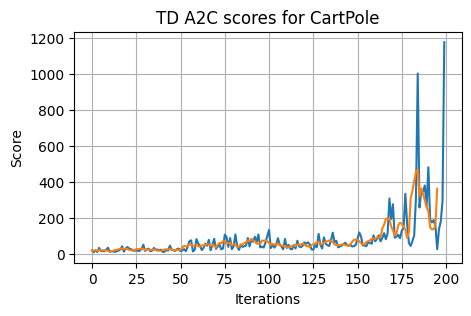

In [27]:
def plot_moving_avg(data, window_size):
    if not data: return
    moving_avg = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg)

plt.figure(figsize=(5,3))
plt.plot(scores)
plot_moving_avg(scores,5)
plt.title('TD A2C scores for CartPole')
plt.ylabel('Score')
plt.xlabel('Iterations')
plt.grid()
plt.show()

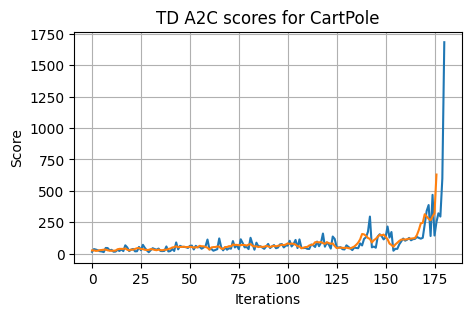

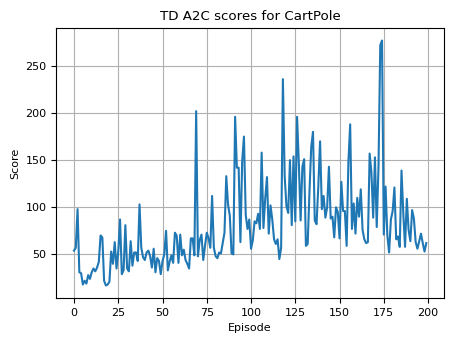

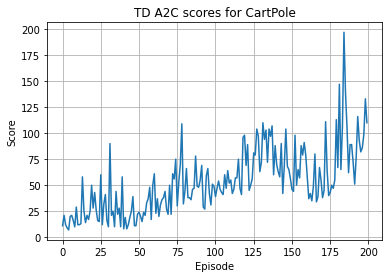

In [ ]:
#actor.save(path+"models/DRL/cartpole_by_A2C.keras")
actor = keras.models.load_model(path+"models/DRL/cartpole_by_A2C.keras")

## Evaluation

In [ ]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env(env, path=path, name_prefix="A2C")

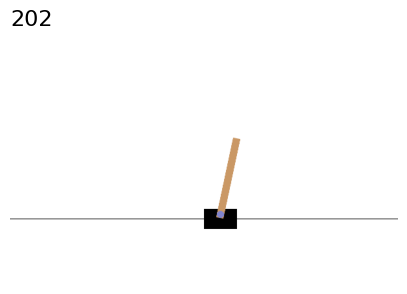

In [ ]:
state, _ = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict = actor.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, info, _ = env_v.step(action)
    if done:  break;
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path,name_prefix='A2C')

/content/gdrive/MyDrive/Colab Notebooks/video/A2C-episode-1.mp4


# 실습과제  
## Actor-Critic Network 결합 모델을 만들어 학습 해 보자   


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 4)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_24 (Dense)          │ (None, 64)             │            320 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_25 (Dense)          │ (None, 64)             │          4,160 │ dense_24[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ actor (Dense)             │ (None, 2)              │            130 │ dense_25[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ critic (Dense)            │ (None, 1)              │             65 │ dense_25[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 4,675 (18.26 KB)

 Trainable params: 4,675 (18.26 KB)

 Non-trainable params: 0 (0.00 B)

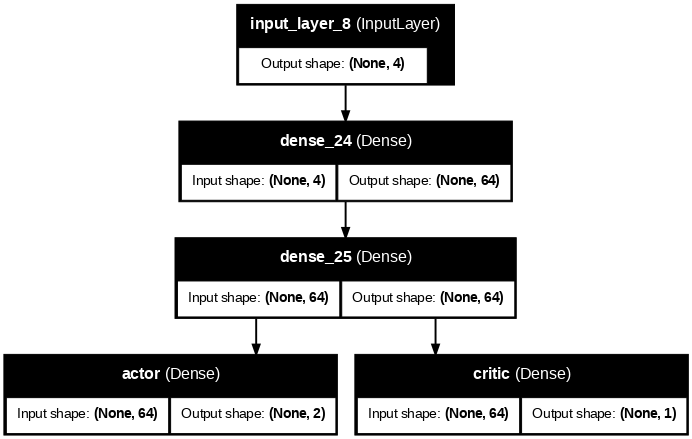

In [ ]:
def ActorCritic(lr=0.01):
    in_layer = keras.Input(shape=(state_size,))
    fc1 = keras.layers.Dense(64, activation="relu",
                             kernel_initializer='he_uniform')(in_layer)
    fc2 = keras.layers.Dense(64, activation="relu")(fc1)

    critic = keras.layers.Dense(1, kernel_initializer='he_uniform',name='critic')(fc2)
    actor = keras.layers.Dense(action_size,activation='softmax',
                               kernel_initializer='he_uniform',name='actor')(fc2)
    actor_critic = keras.Model(inputs=in_layer,outputs=[actor,critic])
    actor_critic.optimizer=Adam(learning_rate=lr,clipnorm=5.0)
    return actor_critic
actor_critic = ActorCritic()
actor_critic.summary()
keras.utils.plot_model(actor_critic,show_shapes=True,show_layer_names=True,dpi=70)

In [ ]:
# A2C(Advantage Actor-Critic) agent for the Cartpole
class A2CAgent:
    def __init__(self, actor_critic):
        # if you want to see Cartpole learning, then change to True
        self.actor_critic = actor_critic
        # get size of state and action
        self.state_size = state_size
        self.action_size = action_size
        self.value_size = 1

        # These are hyper parameters for the Policy Gradient
        self.discount_factor = 0.99
        self.gamma = 0.99

#    def get_action(self, state): ##########

#    def actor_loss(self,prob_a, action, td_error): ##########

    def train_model(self, state, action, reward, next_state, done):
        with tf.GradientTape() as tape:
            _, value = self.actor_critic(state, training=True)

            ### ... ###

            prob_a,_ = self.actor_critic(state.reshape(1,4), training=True)
            a_loss = self.actor_loss(prob_a, action, td_error)

            loss = a_loss + c_loss
        grads = tape.gradient(loss, self.actor_critic.trainable_variables)
        self.actor_critic.optimizer.apply_gradients(zip(grads,\
                                self.actor_critic.trainable_variables))
        return (loss,a_loss,c_loss)

In [ ]:
%%time
# make A2C agent
actor_critic = ActorCritic()
agent = A2CAgent(actor_critic)

n_eps = 200
mean_score = 0
print_every = 2
max_steps = 200
scores, episodes = [], []

for ep in range(n_eps):
    done = False
    score = 0
    state = env.reset()
    state = np.reshape(state, [1, state_size])
    while True:
    ### ... ###
        losses = agent.train_model(state, action, reward, next_state, done)
    ### ... ###
        if done: break
    score = score if score > max_steps else score + 100 # 벌점 보상
    scores.append(score)
    episodes.append(ep)
    mean_score = np.mean(scores[-min(10,len(scores)):])
    if ep % print_every == 0:
        print(f"Episode {ep} || mean_score: {mean_score:0.1f} ||  Actor_Loss: {losses[1]}, Critic_loss:{losses[2]}")
    if mean_score > 200: break


In [ ]:
import matplotlib.pyplot as plt

plt.plot(scores)
plt.title('Shared A2C scores for CartPole')
plt.ylabel('Score')
plt.xlabel('Episode')
plt.grid()
plt.show()

## Evaluation

In [ ]:
%%time
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env(env, path=path, name_prefix="A2C2")

In [ ]:
state = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict,_ = actor_critic.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, _ = env_v.step(action)
    if done:  break;
    cnt += 1
env_v.close()